# Spring of Code - Artificial Intelligence

## Week 08: Deep Learning

### Day 01: Convolutional Neural Networks

In this notebook, we will learn the theoretical foundations of **Convolutional Neural Networks (CNNs)** using TensorFlow and the Keras Sequential API.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


## Load CIFAR-10 Dataset


In [2]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to be between 0 and 1
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels (converting integers into 10-length arrays)
y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("Data loaded and normalized successfully.")

Data loaded and normalized successfully.


## Visualize the Dataset
Let's take a look at a few sample images and their corresponding labels before we train the model.


In [13]:
len(x_train_full)

50000

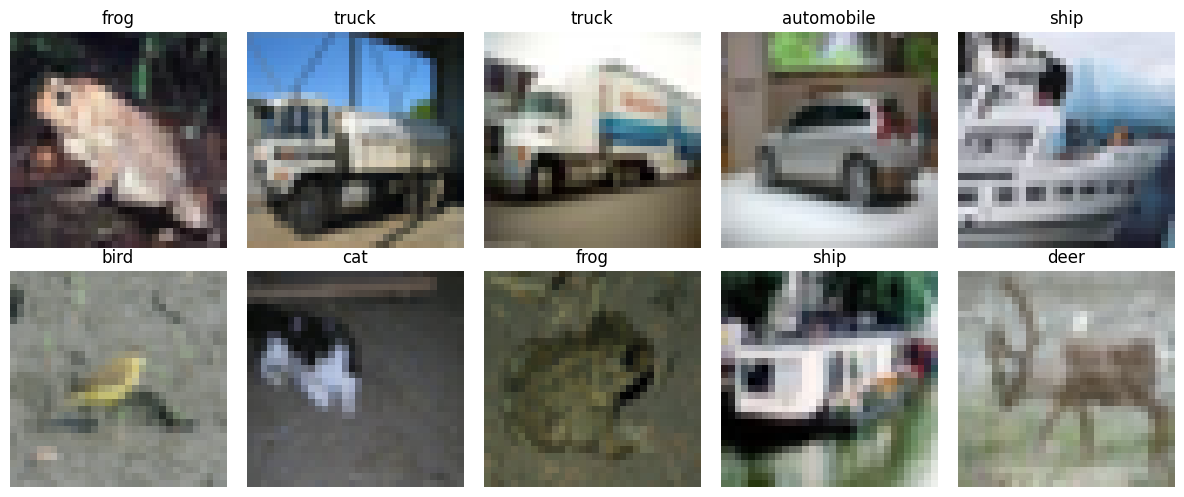

In [11]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    index = np.random.randint(0,len(x_train_full))
    plt.imshow(x_train_full[index])
    plt.title(classes[np.argmax(y_train_full[index])])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Split trainset into train and validation sets
We will take 90% of the training data for actual training, and keep 10% for validation during the epochs.


In [14]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42
)

print(f"Classes: {classes}")
print(f"Training samples: {x_train.shape[0]}, Validation samples: {x_val.shape[0]}")

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training samples: 45000, Validation samples: 5000


## Define the SimpleCNN Architecture
We will use `tf.keras.Sequential` to build our Convolutional Neural Network. 
The layers mirror our theoretical structure:
*   Conv2D $\rightarrow$ BatchNormalization $\rightarrow$ **ReLU** $\rightarrow$ MaxPooling2D


In [16]:
# Instantiate the model using the Sequential API
model = models.Sequential([
    # Input layer
    layers.Input(shape=(32, 32, 3)),
    
    # Block 1
    layers.Conv2D(32, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 2
    layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Block 3
    layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    # Fully Connected Classifier Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

View the Architecture Summary


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

## Define Loss Function and Optimizer
We use Categorical Crossentropy for multi-class tasks, and standard Stochastic Gradient Descent (SGD) with a learning rate of 0.01.


In [19]:
# Compile the model
model.compile(
    optimizer=optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Training configuration successfully defined.")

Training configuration successfully defined.


## Train the Model
Unlike manual loops, Keras allows us to perform the entire training loop using `model.fit()`.


In [20]:
num_epochs = 10
batch_size = 32

print("Starting training...")
# The fit function returns a 'history' object containing all our loss/accuracy metrics
history = model.fit(
    x_train, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val),
    verbose=1
)

print("\nTraining completed!")

Starting training...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.4297 - loss: 1.5788 - val_accuracy: 0.4500 - val_loss: 1.4965
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.5494 - loss: 1.2589 - val_accuracy: 0.4724 - val_loss: 1.5354
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - accuracy: 0.6057 - loss: 1.1084 - val_accuracy: 0.4664 - val_loss: 1.5662
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 47s 33ms/step - accuracy: 0.6414 - loss: 1.0095 - val_accuracy: 0.6270 - val_loss: 1.0419
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 47s 34ms/step - accuracy: 0.6659 - loss: 0.9441 - val_accuracy: 0.5196 - val_loss: 1.5561
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.6901 - loss: 0.8830 - val_accuracy: 0.5064 - val_loss: 1.6462
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 33ms/step - accuracy: 0.7057 - loss: 0.8338 - val_accuracy: 0.6918 - val_loss: 0.8487
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step

## Visualize Training Results
Let's plot the history to check for overfitting and see how well our model converges.


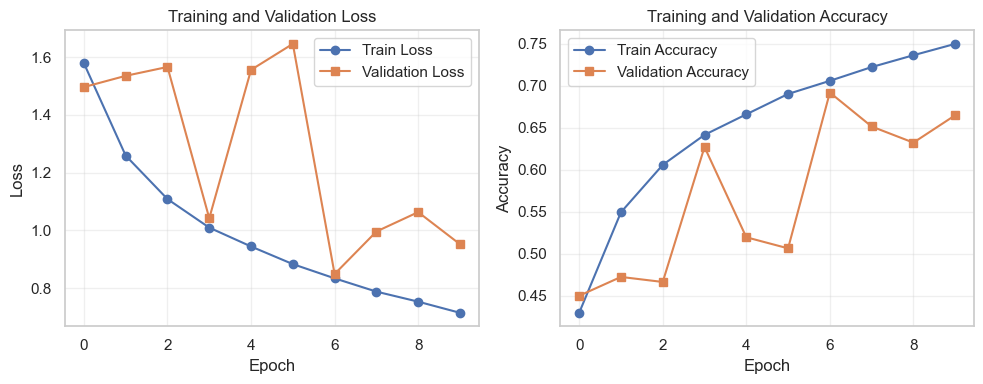


Final Validation Accuracy: 66.48%


In [21]:
import seaborn as sns

sns.set_theme(style="whitegrid")

# Plot training results
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Loss plot
axes[0].plot(history.history['loss'], label="Train Loss", marker="o")
axes[0].plot(history.history['val_loss'], label="Validation Loss", marker="s")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and Validation Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label="Train Accuracy", marker="o")
axes[1].plot(history.history['val_accuracy'], label="Validation Accuracy", marker="s")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training and Validation Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

## Evaluate on unseen Test Set


In [22]:
print("Evaluating on the test dataset...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Set Accuracy: {test_acc*100:.2f}%")

Evaluating on the test dataset...
Test Set Accuracy: 66.89%


## Visualize Model Predictions
Finally, let's take some images from the test set and see how our model's predictions compare to the actual true labels.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


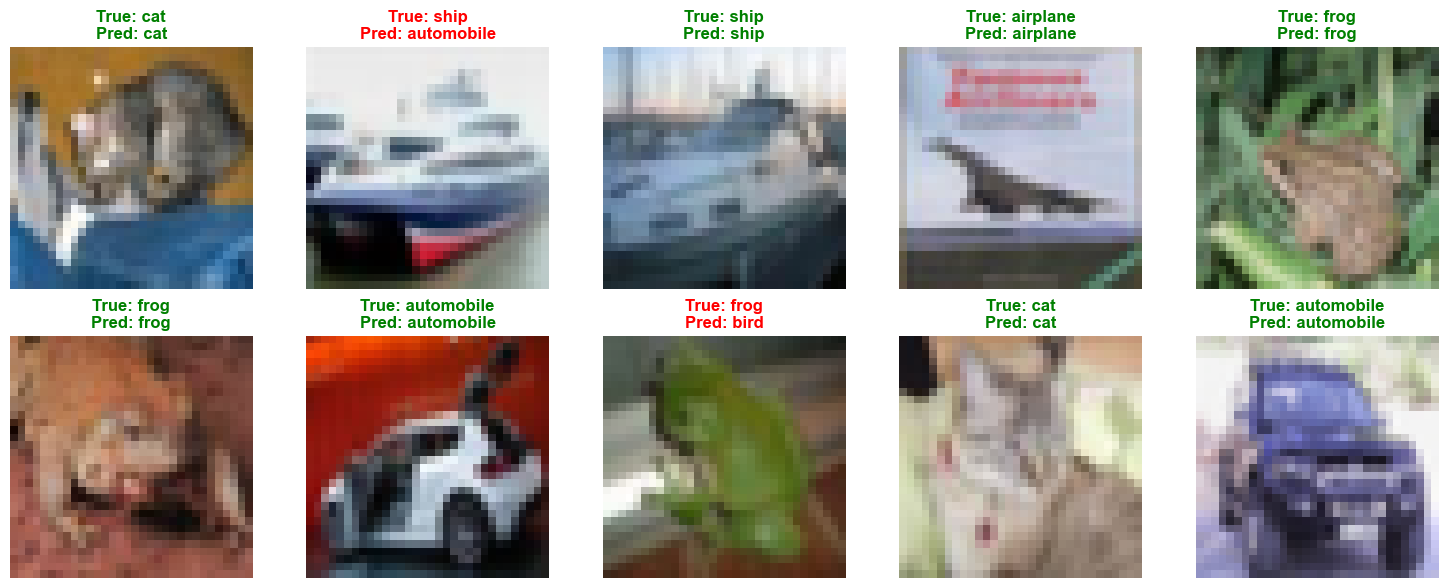

In [23]:
predictions = model.predict(x_test[:10])

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i])
    
    true_label = classes[np.argmax(y_test[i])]
    pred_label = classes[np.argmax(predictions[i])]
    
    # Color the title green if correct, red if incorrect
    color = 'green' if true_label == pred_label else 'red'
    
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

## Confusion Matrix
Let's visualize where our model is getting confused across the 10 classes by plotting a heatmap of the confusion matrix.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


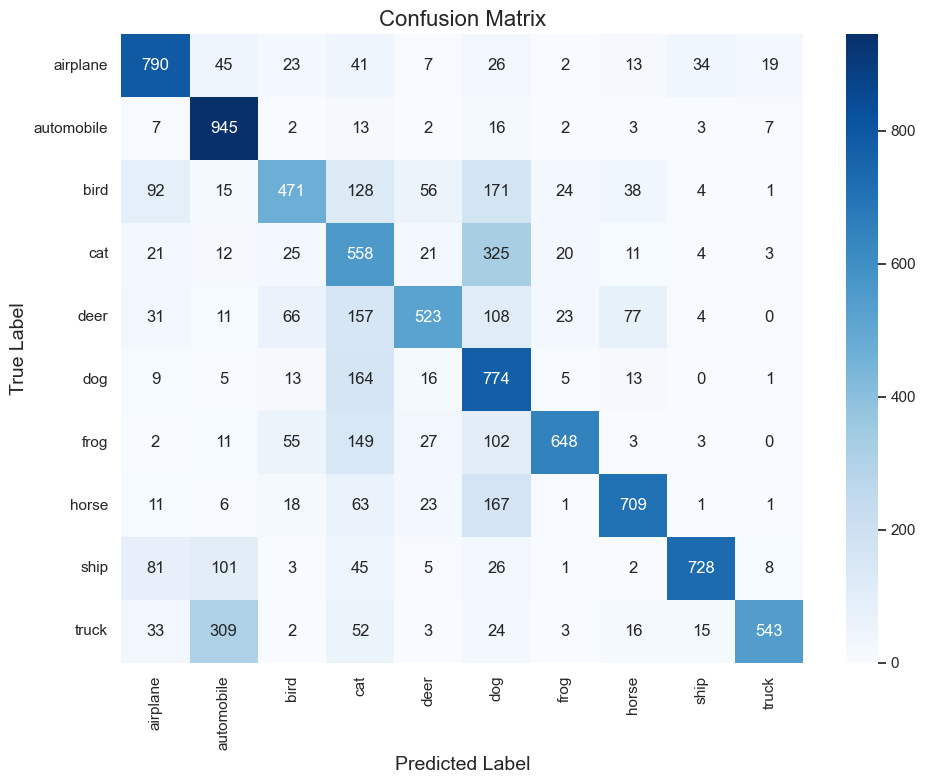

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions for the entire test set
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
model.save('simpe_cnn_cifar10.keras')